

#**MiniMax Algorithm**



In [ ]:

import heapq

def ucs(graph, start, goal):
    pq = [(0, start, [start])]
    visited = set()

    while pq:
        cost, node, path = heapq.heappop(pq)

        if node == goal:
            return path, cost

        if node not in visited:
            visited.add(node)

            for neighbor, edge_cost in graph.get(node, []):
                heapq.heappush(pq, (cost + edge_cost, neighbor, path + [neighbor]))

    return None, float("inf")


graph = {
    'S': [('A', 3), ('B', 2), ('C', 7)],
    'A': [('D', 3), ('E', 8), ('G', 15)],
    'B': [('G', 20)],
    'C': [('G', 6)],
    'D': [],
    'E': [],
    'G': []
}

path, cost = ucs(graph, 'S', 'G')

print("Path:", " → ".join(path))
print("Cost:", cost)

Path: S → C → G
Cost: 13


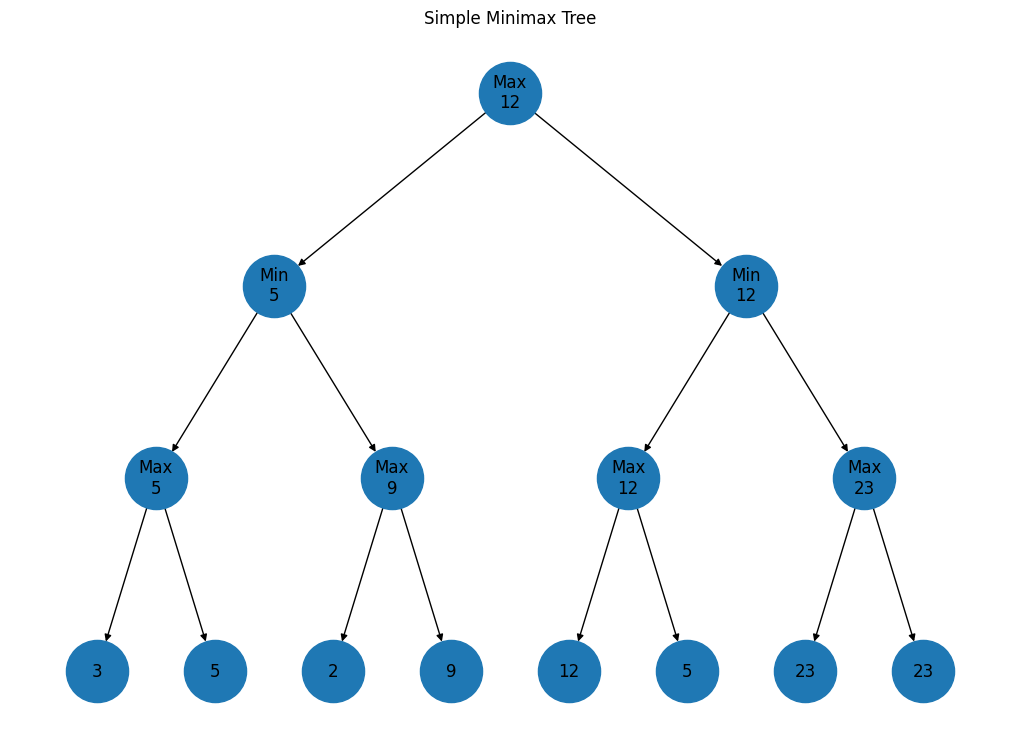

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import math

values = [3, 5, 2, 9, 12, 5, 23, 23]

G = nx.DiGraph()

def build_tree(node, depth, index, height):
    if depth == height:
        G.add_node(node, label=str(values[index]))
        return values[index]

    left = build_tree(node*2+1, depth+1, index*2, height)
    right = build_tree(node*2+2, depth+1, index*2+1, height)

    if depth % 2 == 0:
        value = max(left, right)
        label = f"Max\n{value}"
    else:
        value = min(left, right)
        label = f"Min\n{value}"

    G.add_node(node, label=label)
    G.add_edge(node, node*2+1)
    G.add_edge(node, node*2+2)

    return value


def hierarchy_pos(G, node=0, x=0.5, y=1.0, dx=0.25, pos=None):
    if pos is None:
        pos = {node: (x, y)}
    children = list(G.successors(node))

    if len(children) == 2:
        pos[children[0]] = (x - dx, y - 0.2)
        pos[children[1]] = (x + dx, y - 0.2)

        pos = hierarchy_pos(G, children[0], x - dx, y - 0.2, dx/2, pos)
        pos = hierarchy_pos(G, children[1], x + dx, y - 0.2, dx/2, pos)

    return pos


height = int(math.log2(len(values)))
build_tree(0, 0, 0, height)

pos = hierarchy_pos(G)

labels = nx.get_node_attributes(G, 'label')

plt.figure(figsize=(10,7))
nx.draw(G, pos, with_labels=False, node_size=2000)
nx.draw_networkx_labels(G, pos, labels)

plt.title("Simple Minimax Tree")
plt.axis('off')
plt.show()

In [ ]:
def minimax(depth, index, is_max, height):

    if depth == height:
        return values[index]

    if is_max:
        left = minimax(depth + 1, index * 2, False, height)
        right = minimax(depth + 1, index * 2 + 1, False, height)
        return max(left, right)

    else:
        left = minimax(depth + 1, index * 2, True, height)
        right = minimax(depth + 1, index * 2 + 1, True, height)
        return min(left, right)


optimal_value = minimax(0, 0, True, height)

print("Optimal Value (Minimax):", optimal_value)

Optimal Value (Minimax): 12
